# 4.3 Render a million observations as statistics

**Learning objectives:** distinguish aggregation from sampling; control canvas resolution; measure time and memory honestly.

**How to learn:** predict - run - explain - change one thing. Spend 45–90 minutes here.

**Data:** the default worked example is deterministic synthetic practice data near Colorado. It is not SNOTEL, a watershed survey, a burn map, or a foundation-model output.


## Before you run

Datashader maps all input records into display pixels. A pixel is a statistic, not an individually selectable observation. Our million-point fixture is intentionally synthetic; increasing display resolution does not create new information.


In [ ]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"course.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from course import OUT, points


## Aggregate raw points, without H3


{'rows': 1000000, 'memory_MB': np.float64(62.890132), 'seconds': 1.6431298999996216}


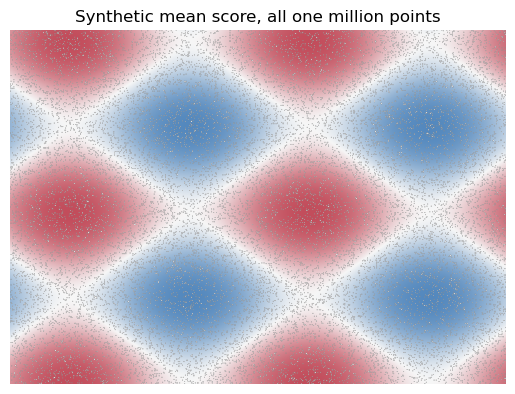

In [2]:
import datashader as ds
import datashader.transfer_functions as tf
from time import perf_counter
frame=points(1_000_000)
frame['probability']=1/(1+np.exp(-frame.signal))
canvas=ds.Canvas(plot_width=700,plot_height=500,x_range=(-105.32,-105.12),y_range=(39.88,40.08))
t0=perf_counter()
aggregate=canvas.points(frame,'longitude','latitude',ds.mean('probability'))
elapsed=perf_counter()-t0
counts=canvas.points(frame,'longitude','latitude',ds.count())
assert int(counts.sum())==len(frame)
img=tf.shade(aggregate,cmap=['#2166ac','#f7f7f7','#b2182b'],how='linear',span=(0,1))
img.to_pil().save(OUT/'synthetic_full_resolution.png')
print(dict(rows=len(frame),memory_MB=frame.memory_usage(deep=True).sum()/1e6,seconds=elapsed))
plt.imshow(img.to_pil());plt.axis('off');plt.title('Synthetic mean score, all one million points');plt.show()


## Your turn

Compare 350×250 and 1400×1000 canvases. Repeat timing after the first run. Compare mean aggregation with count aggregation.

Use a new cell below to try this before opening the solution.


In [3]:
# Write your experiment here. The worked example above is already complete.


<details><summary>Solution and reasoning - open after trying</summary>

A larger canvas has more output cells and more sparse pixels. The first run may include JIT compilation, so report cold and warm timings separately. Count measures sample density; mean measures values at sampled locations. Neither is a browser frame-rate measurement.

</details>


## Check yourself

Expected: count aggregation recovers exactly one million records. Why is comparing this Python timing to an HTML export time unfair? How could you measure actual browser interaction?

**Exit ticket:** write one result, one explanation, and one limitation. Save the notebook with your own observations.


## Transfer to real data

For a projected map, transform coordinates before rasterization. For rasters, consider chunked xarray inputs; converting every pixel to a DataFrame can become the memory bottleneck. Do not call this fixture a real full-resolution satellite export.
